# Evaluator: DV Heatmaps across $K$ and $\alpha$

This notebook reads the updated `grun.py` and `srun.py` outputs and generates 2D heatmaps for each dependent variable across `K` and `$\alpha$`.

Expected output files follow this pattern:

`{solver_prefix}_{dv}_across_K_alpha_{alpha}`

where `solver_prefix` is `g` or `s`, and `dv` is one of:

- `breakthrough_fitness`
- `breakthrough_rank`
- `diversity`
- `pairwise_diversity`
- `average_fitness`


In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

legend_properties = {'weight': 'bold'}

# NUS colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi colors
morandi_blue = "#046586"
morandi_green = "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Greys
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

# Red and blue
strong_red = "#A61C5D"
strong_blue = "#1B64A4"

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.linewidth"] = 1.0


In [3]:
# =========================
# User settings
# =========================

# Change this folder to the location where the running scripts saved the pickle outputs.
data_folder = Path(r"/Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity")

# Heatmap figures will be saved here.
figure_folder = data_folder / "heatmap_figures"
figure_folder.mkdir(parents=True, exist_ok=True)

# These should match grun.py and srun.py.
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
alpha_list = [0.025, 0.05, 0.075, 0.10, 0.125, 0.15, 0.175, 0.20, 0.25]

# The scripts save files using str(alpha), e.g., 0.10 becomes "0.1".
alpha_labels = [f"{alpha:g}" for alpha in alpha_list]

solver_meta = {
    "G": {
        "prefix": "g",
        "label": "Generalist",
    },
    "S": {
        "prefix": "s",
        "label": "Specialist",
    },
}

dv_meta = {
    "breakthrough_fitness": {
        "label": "Breakthrough Fitness",
        "colorbar": "Breakthrough fitness",
        "filename_label": "breakthrough_fitness",
    },
    "breakthrough_rank": {
        "label": "Breakthrough Rank",
        "colorbar": "Breakthrough rank",
        "filename_label": "breakthrough_rank",
    },
    "diversity": {
        "label": "Solution Diversity",
        "colorbar": "Number of unique full solutions",
        "filename_label": "diversity",
    },
    "pairwise_diversity": {
        "label": "Pairwise Solution Diversity",
        "colorbar": "Average pairwise normalized distance",
        "filename_label": "pairwise_diversity",
    },
    "average_fitness": {
        "label": "Average Fitness",
        "colorbar": "Average solver fitness",
        "filename_label": "average_fitness",
    },
}


In [4]:
def alpha_token(alpha):
    'Return the exact alpha text used by grun.py and srun.py file names.'
    return str(alpha)


def read_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)


def load_dv_matrix(solver_prefix, dv_name):
    'Load one DV as a matrix with rows = alpha values and columns = K values.'
    matrix = []
    missing_files = []

    for alpha in alpha_list:
        file_name = f"{solver_prefix}_{dv_name}_across_K_alpha_{alpha_token(alpha)}"
        file_path = data_folder / file_name

        if not file_path.exists():
            missing_files.append(str(file_path))
            continue

        values = read_pickle(file_path)
        if len(values) != len(K_list):
            raise ValueError(
                f"{file_path.name} has {len(values)} values, "
                f"but K_list has {len(K_list)} values."
            )
        matrix.append(values)

    if missing_files:
        missing_text = "\n".join(missing_files)
        raise FileNotFoundError(
            "The following output files were not found. "
            "Please check data_folder and the alpha/K settings.\n\n"
            f"{missing_text}"
        )

    matrix = np.asarray(matrix, dtype=float)
    expected_shape = (len(alpha_list), len(K_list))
    if matrix.shape != expected_shape:
        raise ValueError(f"Loaded matrix shape is {matrix.shape}, expected {expected_shape}.")

    return matrix


def load_all_results():
    'Load all solver-DV matrices into a nested dictionary.'
    results = {}
    for solver_key, solver_info in solver_meta.items():
        results[solver_key] = {}
        for dv_name in dv_meta:
            results[solver_key][dv_name] = load_dv_matrix(
                solver_prefix=solver_info["prefix"],
                dv_name=dv_name,
            )
    return results


In [5]:
# Load all DVs for G and S.
results = load_all_results()

for solver_key, dv_dict in results.items():
    for dv_name, matrix in dv_dict.items():
        print(f"{solver_key} | {dv_name}: {matrix.shape}")


G | breakthrough_fitness: (9, 8)
G | breakthrough_rank: (9, 8)
G | diversity: (9, 8)
G | pairwise_diversity: (9, 8)
G | average_fitness: (9, 8)
S | breakthrough_fitness: (9, 8)
S | breakthrough_rank: (9, 8)
S | diversity: (9, 8)
S | pairwise_diversity: (9, 8)
S | average_fitness: (9, 8)


In [6]:
def plot_dv_heatmap(solver_key, dv_name, cmap="jet", dpi=300):
    'Plot and save one heatmap for one solver type and one DV.'
    solver_info = solver_meta[solver_key]
    dv_info = dv_meta[dv_name]
    z = results[solver_key][dv_name]

    fig, ax = plt.subplots(figsize=(6.6, 4.8))
    mesh = ax.pcolormesh(K_list, alpha_list, z, cmap=cmap, shading="auto")
    colorbar = fig.colorbar(mesh, ax=ax)
    colorbar.set_label(dv_info["colorbar"])

    ax.set_xlabel("K")
    ax.set_ylabel(r"$\alpha$")
    ax.set_xticks(K_list)
    ax.set_yticks(alpha_list)
    ax.set_yticklabels(alpha_labels)
    ax.set_title(f"{solver_info['label']} {dv_info['label']} across $K$ and $\\alpha$")

    fig.tight_layout()

    output_path = figure_folder / f"{solver_info['prefix']}_{dv_info['filename_label']}_heatmap.png"
    fig.savefig(output_path, transparent=True, dpi=dpi)
    plt.show()
    print(f"Saved: {output_path}")


def plot_all_dv_heatmaps(cmap="jet", dpi=300):
    'Plot and save all G/S heatmaps for all DVs.'
    for dv_name in dv_meta:
        for solver_key in solver_meta:
            plot_dv_heatmap(solver_key=solver_key, dv_name=dv_name, cmap=cmap, dpi=dpi)


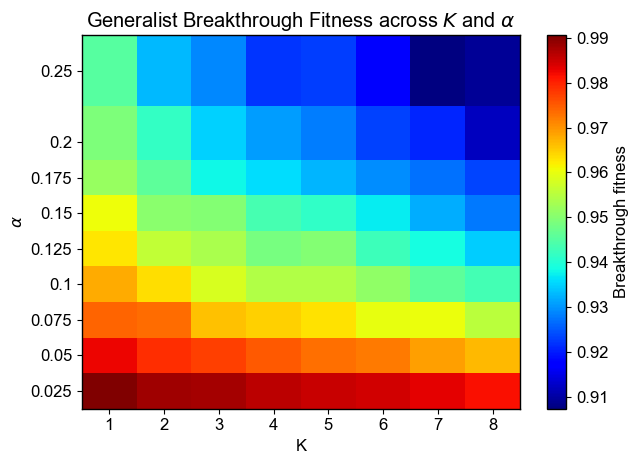

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/g_breakthrough_fitness_heatmap.png


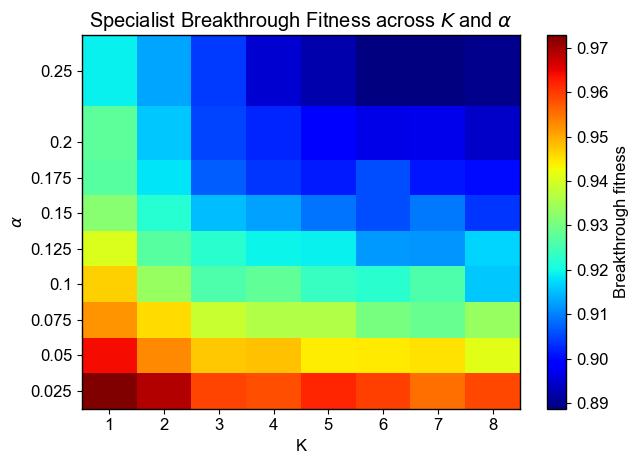

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/s_breakthrough_fitness_heatmap.png


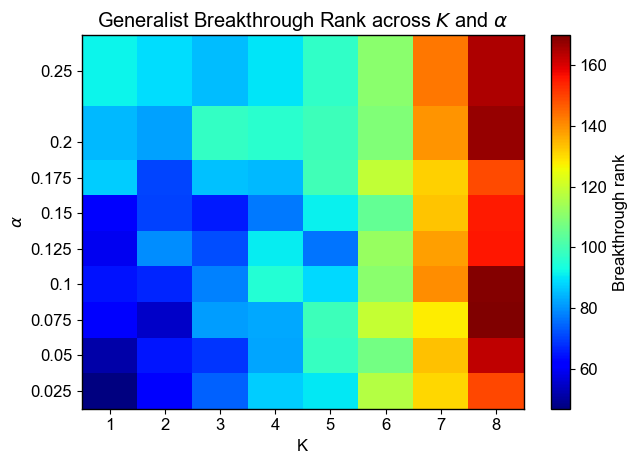

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/g_breakthrough_rank_heatmap.png


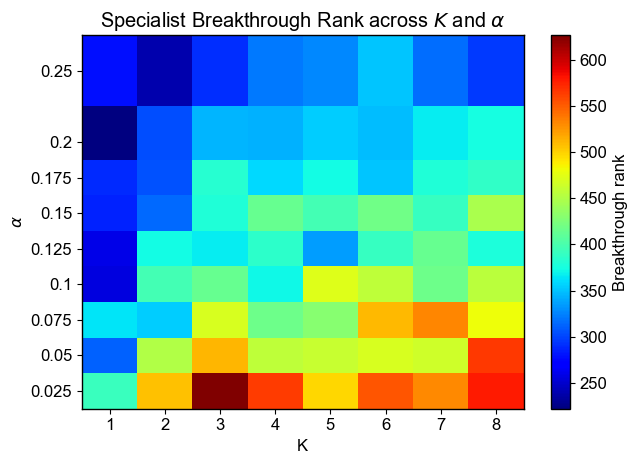

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/s_breakthrough_rank_heatmap.png


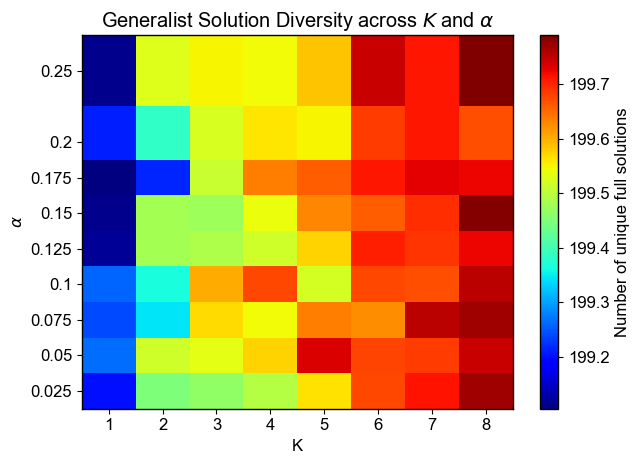

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/g_diversity_heatmap.png


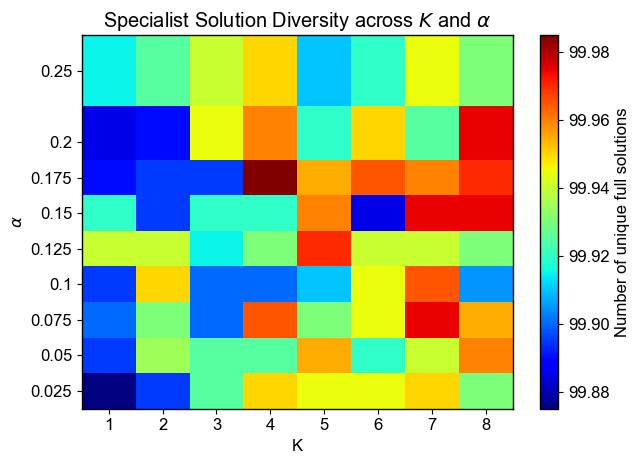

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/s_diversity_heatmap.png


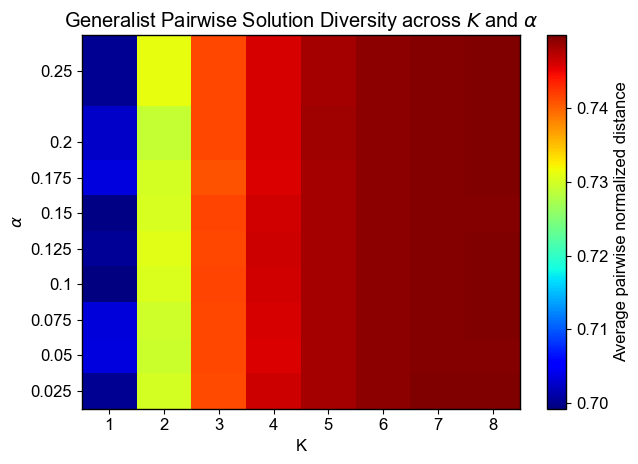

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/g_pairwise_diversity_heatmap.png


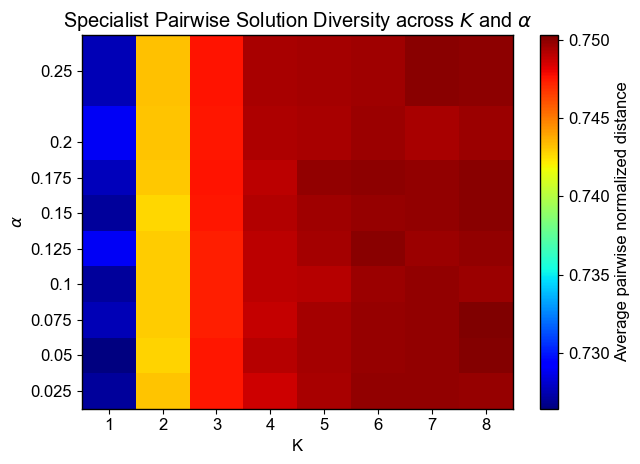

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/s_pairwise_diversity_heatmap.png


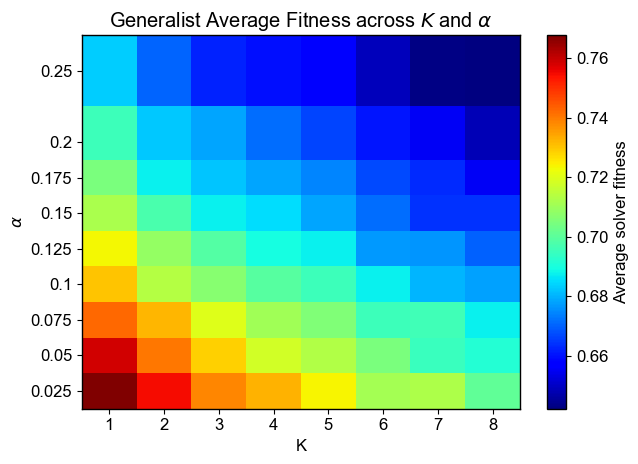

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/g_average_fitness_heatmap.png


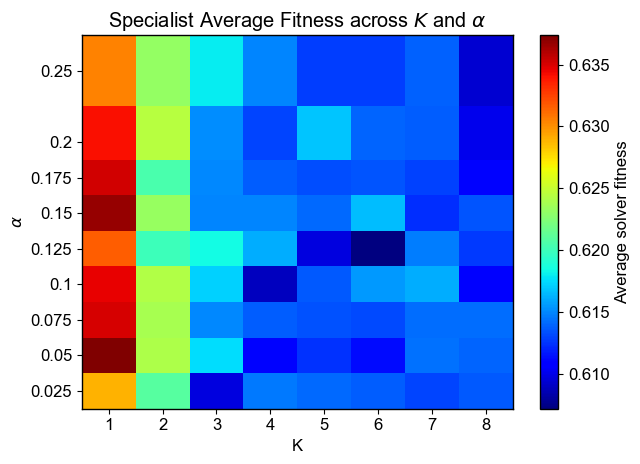

Saved: /Volumes/T7/data/gst-0112-26/Appendix/TwoComplexity/heatmap_figures/s_average_fitness_heatmap.png


In [7]:
# Generate all heatmap figures.
plot_all_dv_heatmaps(cmap="jet", dpi=300)


## Optional: generate only selected figures

Use the cell below when you only want one solver-DV figure instead of the full batch. For example, `plot_dv_heatmap("G", "average_fitness")` will generate only the generalist average-fitness heatmap.


In [8]:
# Examples:
# plot_dv_heatmap("G", "breakthrough_fitness")
# plot_dv_heatmap("S", "breakthrough_fitness")
# plot_dv_heatmap("G", "breakthrough_rank")
# plot_dv_heatmap("S", "breakthrough_rank")
# plot_dv_heatmap("G", "diversity")
# plot_dv_heatmap("S", "diversity")
# plot_dv_heatmap("G", "pairwise_diversity")
# plot_dv_heatmap("S", "pairwise_diversity")
# plot_dv_heatmap("G", "average_fitness")
# plot_dv_heatmap("S", "average_fitness")
